<a href="https://colab.research.google.com/github/m1deey/First_project/blob/main/Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/m1deey/First_project.git

Cloning into 'First_project'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 25 (delta 5), reused 7 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 294.28 KiB | 10.51 MiB/s, done.
Resolving deltas: 100% (5/5), done.


Our data

In [ ]:
import pandas as pd

# Load the Titanic dataset from your cloned repository
df = pd.read_csv('First_project/train.csv')
# Look at the first few rows to make sure it loaded correctly
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
import numpy as np

df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

df['Has_Cabin'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
df = df.drop(columns=['Cabin'])

df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Is_Alone'] = np.where(df['Family_Size'] == 1, 1, 0)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
age_bins = [0, 12, 18, 35, 60, 80]
age_labels = [0, 1, 2, 3, 4]
age_bins = [0, 12, 18, 35, 60, 80]
age_labels = ['Child', 'Teenager', 'Young_Adult', 'Adult', 'Senior']


df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

df = pd.get_dummies(df, columns=['Age_Group'], prefix='Age', dtype=int)
df = df.drop(columns=['Age'])
fare_labels = ['Low_Fare', 'Medium_Fare', 'High_Fare', 'Luxury_Fare']
df['Fare_Group'] = pd.qcut(df['Fare'], q=4, labels=fare_labels)

df = pd.get_dummies(df, columns=['Fare_Group'], prefix='Fare', dtype=int)
df = df.drop(columns=['Fare'])






df.head()

,Survived,Pclass,Sex,SibSp,Parch,Embarked,Has_Cabin,Family_Size,Is_Alone,Age_Child,Age_Teenager,Age_Young_Adult,Age_Adult,Age_Senior,Fare_Low_Fare,Fare_Medium_Fare,Fare_High_Fare,Fare_Luxury_Fare
0,0,3,1,1,0,0,0,2,0,0,0,1,0,0,1,0,0,0
1,1,1,0,1,0,1,1,2,0,0,0,0,1,0,0,0,0,1
2,1,3,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0
3,1,1,0,1,0,0,1,2,0,0,0,1,0,0,0,0,0,1
4,0,3,1,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0


#Cleaning
After we cleaned the data it's time to test it for predictions

We import our sklearn libraries
Then we split our data to train data and test data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
x=df.drop(columns=["Survived"])
y=df["Survived"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#Training the model

In [ ]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

#Make predictions

In [ ]:
y_pred=model.predict(x_test)

#Checking the accuracy

In [ ]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 80.45%


#Let's see what it can do

In [ ]:
print(y_test[:10])
print(y_pred[:10])

709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
Name: Survived, dtype: int64
[1 0 0 1 0 1 1 0 0 1]


The models predicted 8/10 from the training

#The steps:
.cleaned the data
.trained the data
.test the data
.checked the accuracy
.runed the model

#Next
We want to know where to model get answers wrong and we have to use the confusing matrix

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[91 14]
 [21 53]]


Next vasules it

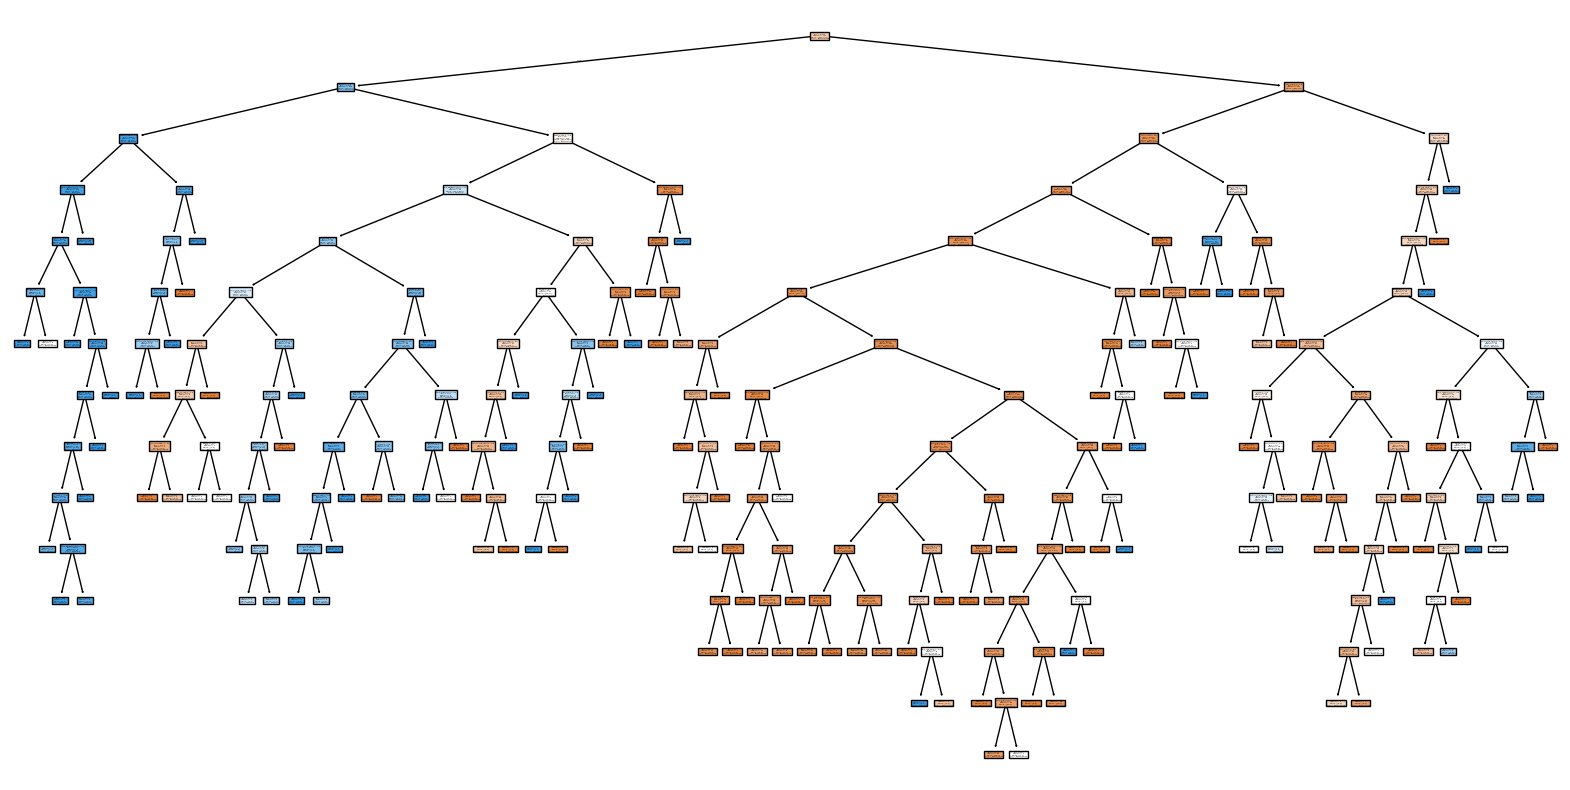

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model,feature_names=x.columns,class_names=["Not survived","Survived"],filled=True)
plt.show()

From the tree we concluded that we have kver fitting but before fixing it lets compare this to Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
leg_reg=LogisticRegression(max_iter=1000)
leg_reg.fit(x_train,y_train)
y_lr_prd=leg_reg.predict(x_test)
lr_accuracy=accuracy_score(y_test,y_lr_prd)
print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_lr_prd)
print(cm_lr)

Logistic Regression Accuracy: 81.01%
[[89 16]
 [18 56]]


The logistic regression accuracy is better now we will try to make the lg tree have better accuracy

In [ ]:
model_tuned = DecisionTreeClassifier(max_depth=3, random_state=42)
model_tuned.fit(x_train, y_train)

y_pred_tuned = model_tuned.predict(x_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Decision Tree Accuracy: {tuned_accuracy:.2%}")

Tuned Decision Tree Accuracy: 80.45%


We still have work to let's try do random forest to make combined decisions trees

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)

y_rf_pred = rf_model.predict(x_test)
rf_accuracy = accuracy_score(y_test, y_rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 83.24%


Now the Random forest have better accuracy
Now lets see what is the most important decisions

In [ ]:
import numpy as np

importances = rf_model.feature_importances_
for feature, importance in zip(x_train.columns, importances):
    print(f"{feature}: {importance:.2%}")

Pclass: 11.61%
Sex: 37.04%
SibSp: 4.28%
Parch: 3.83%
Embarked: 6.12%
Has_Cabin: 6.52%
Family_Size: 7.59%
Is_Alone: 1.43%
Age_Child: 4.39%
Age_Teenager: 1.37%
Age_Young_Adult: 2.70%
Age_Adult: 1.90%
Age_Senior: 0.88%
Fare_Low_Fare: 2.40%
Fare_Medium_Fare: 2.16%
Fare_High_Fare: 2.14%
Fare_Luxury_Fare: 3.62%


#Final
For the final step let's creat our prediction table

In [ ]:
import pandas as pd


results_data = {
    "Model Name": ["Original Decision Tree", "Tuned Decision Tree (Depth 3)", "Logistic Regression", "Random Forest (Depth 10)"],
    "Accuracy Score": ["79.89%", "80.45%", "81.01%", "83.24%"],
    "Status": ["Overfitted Baseline", "Optimized Tree", "Strong Baseline", "<Champion Model> "]
}


df_results = pd.DataFrame(results_data)
print(df_results.to_markdown(index=False))

| Model Name                    | Accuracy Score   | Status              |
|:------------------------------|:-----------------|:--------------------|
| Original Decision Tree        | 79.89%           | Overfitted Baseline |
| Tuned Decision Tree (Depth 3) | 80.45%           | Optimized Tree      |
| Logistic Regression           | 81.01%           | Strong Baseline     |
| Random Forest (Depth 10)      | 83.24%           | <Champion Model>    |
